## 🤖 Model Training
#### Bank Loan Default Analytics

---

> **Notebook 3 of 5**  
> **Goal:** Train multiple machine learning models to predict loan default risk, handle class imbalance using SMOTE, and select the best performing model.  
> **Input:** `data/processed/engineered_data.csv`  
> **Output:** `models/best_model.pkl` (saved trained model)

### Step 1 — Importing Libraries

In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### Step 2 — Load Engineered Data

In [9]:
df = pd.read_csv('../data/processed/engineered_data.csv')

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Target distribution:\n{df['TARGET'].value_counts()}")

✅ Data loaded: 307,511 rows × 78 columns
🎯 Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


### Step 3 — Preparing Features & Target
Separating features (X) and target (y), then splitting into train and test sets.

In [10]:
# Separate features and target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Default rate   : {y.mean()*100:.2f}%")

Features shape : (307511, 76)
Target shape   : (307511,)
Default rate   : 8.07%


In [11]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate : {y_test.mean()*100:.2f}%")

Training set   : 246,008 rows
Test set       : 61,503 rows

Train default rate: 8.07%
Test default rate : 8.07%


In [12]:
# Check for remaining NaN values
print(f"NaN values in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN values in X_test : {X_test.isnull().sum().sum()}")

# Fill any remaining NaNs with median
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

print(f"\nAfter fix:")
print(f"NaN values in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN values in X_test : {X_test.isnull().sum().sum()}")
print("✅ All NaN values handled")

NaN values in X_train: 340797
NaN values in X_test : 85359

After fix:
NaN values in X_train: 0
NaN values in X_test : 0
✅ All NaN values handled


### Step 4 — Handling Class Imbalance with SMOTE
The dataset has ~8% default rate — heavily imbalanced. SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples of the minority class to balance the training data.

In [13]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")
print(f"After SMOTE  — 0: {(y_train_sm==0).sum():,}  |  1: {(y_train_sm==1).sum():,}")
print(f"\n✅ Training data balanced successfully")

Before SMOTE — 0: 226,148  |  1: 19,860
After SMOTE  — 0: 226,148  |  1: 226,148

✅ Training data balanced successfully


### Step 5 — Feature Scaling
Applying StandardScaler to normalize numerical features for Logistic Regression.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully")

✅ Features scaled successfully


### Step 6 — Training Multiple Models
Training 4 models and comparing their performance — Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [15]:
# Define models
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest'       : RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'XGBoost'             : XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Use scaled data for Logistic Regression, unscaled for tree models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_sm)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'accuracy': acc,
        'auc'     : auc
    }
    
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   ROC-AUC  : {auc:.4f}\n")

print("✅ All models trained successfully")

Training Logistic Regression...
   Accuracy : 79.72%
   ROC-AUC  : 0.6399

Training Decision Tree...
   Accuracy : 76.02%
   ROC-AUC  : 0.6396

Training Random Forest...
   Accuracy : 91.14%
   ROC-AUC  : 0.6678

Training XGBoost...
   Accuracy : 91.50%
   ROC-AUC  : 0.7222

✅ All models trained successfully


### Step 7 — Model Comparison
Comparing all models side by side on Accuracy and ROC-AUC score.

In [16]:
# Build comparison dataframe
comparison = pd.DataFrame({
    'Model'   : list(results.keys()),
    'Accuracy': [results[m]['accuracy']*100 for m in results],
    'ROC-AUC' : [results[m]['auc'] for m in results]
}).sort_values('ROC-AUC', ascending=False)

print(comparison.to_string(index=False))

              Model  Accuracy  ROC-AUC
            XGBoost   91.5045   0.7222
      Random Forest   91.1354   0.6678
Logistic Regression   79.7229   0.6399
      Decision Tree   76.0158   0.6396


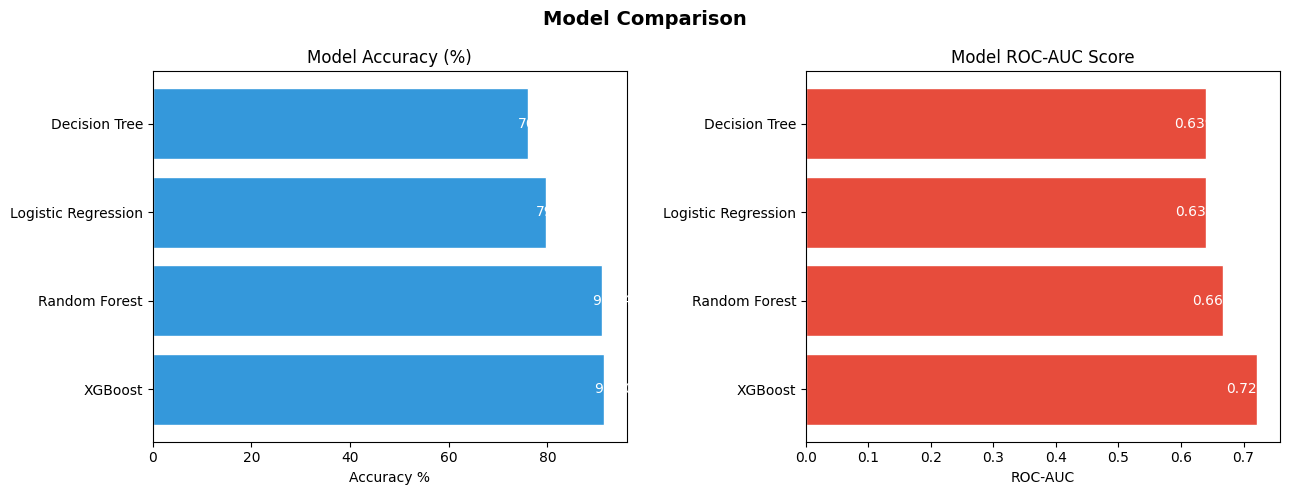

✅ Chart saved to images/model_comparison.png


In [17]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
axes[0].barh(comparison['Model'], comparison['Accuracy'], color='#3498db', edgecolor='white')
axes[0].set_title('Model Accuracy (%)', fontsize=12)
axes[0].set_xlabel('Accuracy %')
for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(v - 2, i, f'{v:.2f}%', va='center', color='white', fontsize=10)

# ROC-AUC
axes[1].barh(comparison['Model'], comparison['ROC-AUC'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Model ROC-AUC Score', fontsize=12)
axes[1].set_xlabel('ROC-AUC')
for i, v in enumerate(comparison['ROC-AUC']):
    axes[1].text(v - 0.05, i, f'{v:.4f}', va='center', color='white', fontsize=10)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/model_comparison.png")

### Step 8 — Best Model Selection & ROC Curve
Selecting the best model based on ROC-AUC and plotting the ROC curve for all models.

In [18]:
# Pick best model by ROC-AUC
best_model_name = comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"🏆 Best Model  : {best_model_name}")
print(f"   Accuracy   : {results[best_model_name]['accuracy']*100:.2f}%")
print(f"   ROC-AUC    : {results[best_model_name]['auc']:.4f}")

🏆 Best Model  : XGBoost
   Accuracy   : 91.50%
   ROC-AUC    : 0.7222


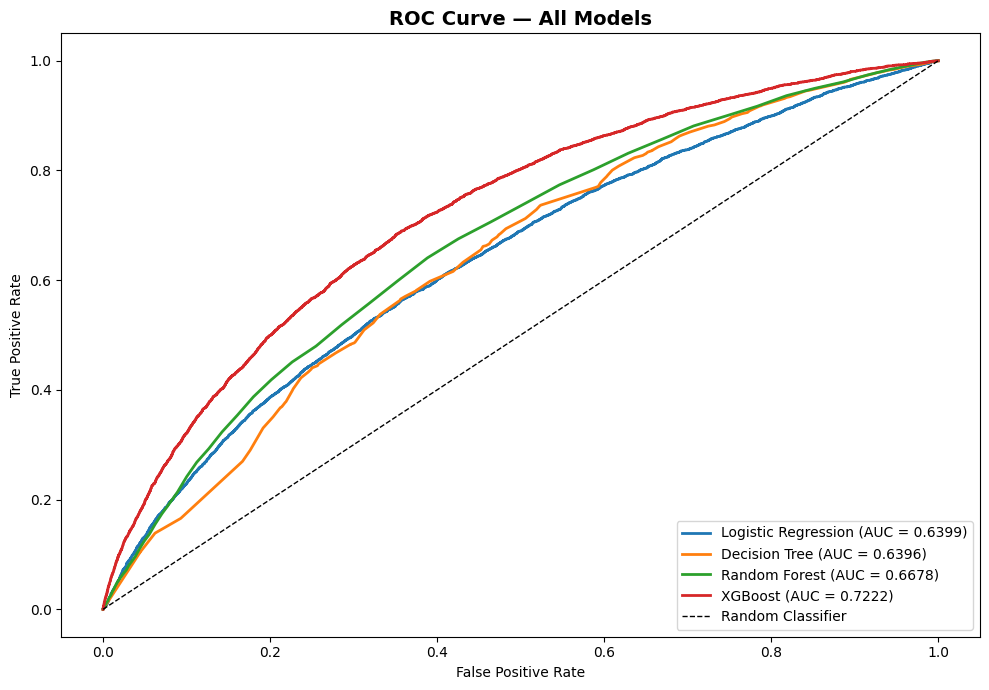

✅ Chart saved to images/roc_curve.png


In [19]:
# ROC Curve for all models
plt.figure(figsize=(10, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})", linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/roc_curve.png")

### Step 9 — Confusion Matrix & Classification Report
Detailed evaluation of the best model — precision, recall, F1 score.

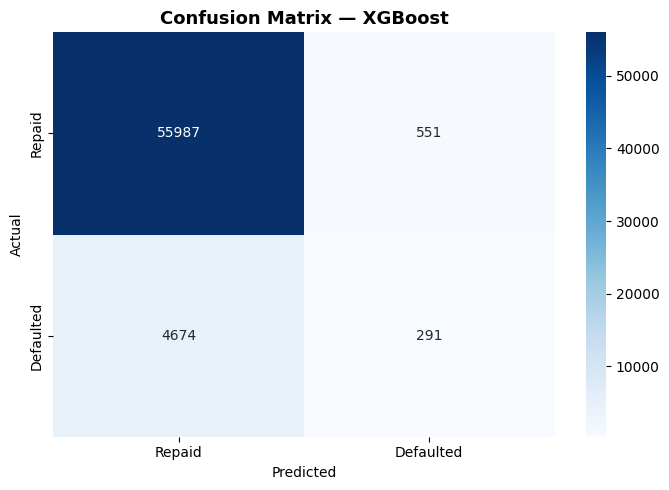


Classification Report:
              precision    recall  f1-score   support

      Repaid       0.92      0.99      0.96     56538
   Defaulted       0.35      0.06      0.10      4965

    accuracy                           0.92     61503
   macro avg       0.63      0.52      0.53     61503
weighted avg       0.88      0.92      0.89     61503



In [20]:
# Confusion matrix for best model
y_pred_best = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Repaid', 'Defaulted']))

### Step 10 — Feature Importance
Identifying which features contributed most to the best model's predictions.

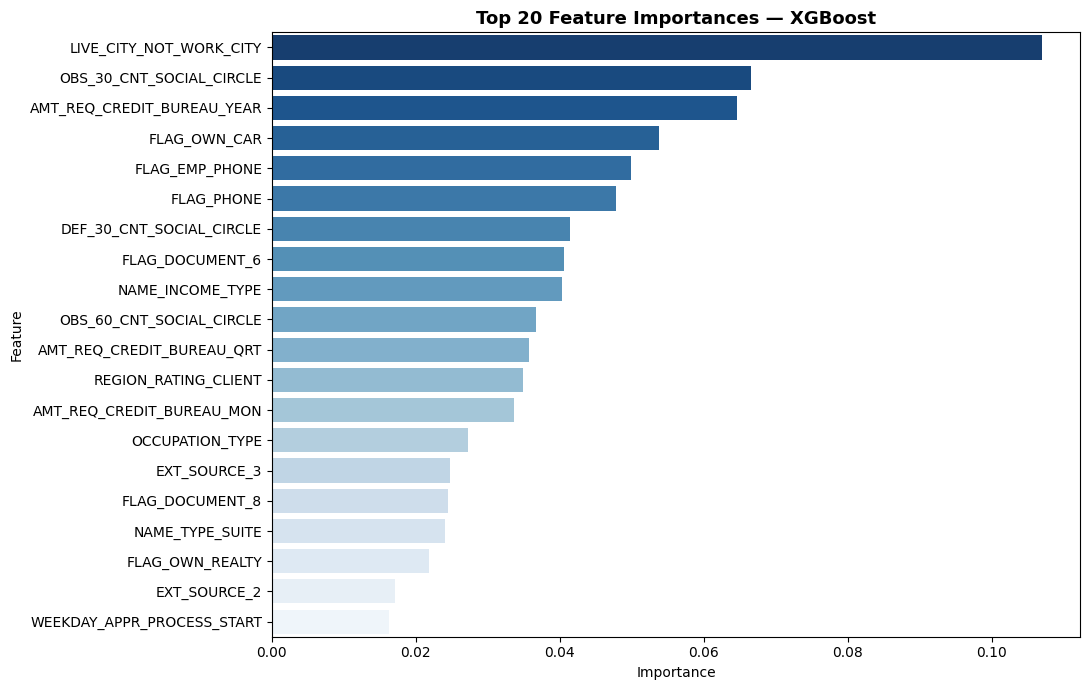

✅ Chart saved to images/feature_importance.png


In [21]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature'   : X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(11, 7))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_r')
    plt.title(f'Top 20 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart saved to images/feature_importance.png")
else:
    print("ℹ️ Feature importance not available for Logistic Regression")

### Step 11 — Saving the Best Model
Saving the best model and scaler to the `models/` folder for use in the Streamlit dashboard.

In [22]:
# Save best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(f"✅ Best model saved   : models/best_model.pkl")
print(f"✅ Scaler saved       : models/scaler.pkl")
print(f"✅ Feature names saved: models/feature_names.pkl")

✅ Best model saved   : models/best_model.pkl
✅ Scaler saved       : models/scaler.pkl
✅ Feature names saved: models/feature_names.pkl


### Step 12 — Model Training Summary

In [23]:
print("=" * 55)
print("      MODEL TRAINING SUMMARY")
print("=" * 55)
print(f"\n🏆 Best Model  : {best_model_name}")
print(f"   Accuracy   : {results[best_model_name]['accuracy']*100:.2f}%")
print(f"   ROC-AUC    : {results[best_model_name]['auc']:.4f}")
print(f"\n📊 All Models:")
for name, res in results.items():
    print(f"   {name:<25} Acc: {res['accuracy']*100:.2f}%  AUC: {res['auc']:.4f}")
print(f"\n💾 Model saved to : models/best_model.pkl")
print("\n✅ Model Training Complete — Moving to SQL Analytics")
print("=" * 55)

      MODEL TRAINING SUMMARY

🏆 Best Model  : XGBoost
   Accuracy   : 91.50%
   ROC-AUC    : 0.7222

📊 All Models:
   Logistic Regression       Acc: 79.72%  AUC: 0.6399
   Decision Tree             Acc: 76.02%  AUC: 0.6396
   Random Forest             Acc: 91.14%  AUC: 0.6678
   XGBoost                   Acc: 91.50%  AUC: 0.7222

💾 Model saved to : models/best_model.pkl

✅ Model Training Complete — Moving to SQL Analytics
